# PhysioNet: entender las series temporales de signos vitales

Este recorrido comienza en un archivo `.psv`, sigue a un paciente y finalmente compara pacientes alineados por `ICULOS`. Estudia **HR, O2Sat, Temp, SBP, MAP, DBP y Resp** sin entrenar modelos.

**Idea central:** una fila es un registro horario de un paciente; `ICULOS` es su tiempo relativo en UCI. La hora 12 de dos pacientes no implica la misma fecha. Las comparaciones siguientes describen evolución clínica y disponibilidad de mediciones; no prueban drift de despliegue.

## 1. Configuración

Ejecuta todas las celdas en orden con el entorno `.venv` del repositorio. Cambia `PATIENT_ID` para explorar otro paciente, `MAX_PATIENTS` para el tamaño de muestra y `MAX_HOUR` para el horizonte de las comparaciones. Las series individuales conservan toda su duración. No se imputan, interpolan ni eliminan valores extremos.


In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "code/src/darl").is_dir()
)
sys.path.insert(0, str(ROOT / "code/src"))
from darl.data.get_dataset import (
    load_physionet_temporal,
    validate_physionet_temporal,
    PHYSIONET_RELATIVE_ROOT,
)

SEED = 42
MAX_PATIENTS = 500000
MAX_HOUR = 60
WINDOW_HOURS = 3
PATIENT_ID = None  # Ejemplo: "b_p114895", si pertenece a la muestra.
DEFAULT_VITALS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]
UNITS = {
    "HR": "latidos/min",
    "O2Sat": "%",
    "Temp": "°C",
    "SBP": "mmHg",
    "MAP": "mmHg",
    "DBP": "mmHg",
    "Resp": "resp/min",
}
DATA_ROOT = ROOT / PHYSIONET_RELATIVE_ROOT
FIG_DIR = ROOT / "outputs/figures/physionet_vitals_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
BLUE, ORANGE = "#28699c", "#bb651b"


def show_figure(fig, name):
    """Save an EDA figure and retain its inline notebook output."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 2. Del archivo al paciente

`load_physionet_temporal` lee los `.psv`, añade `source_set` y construye `patient_id` con la fuente y el nombre del archivo. Ordena por paciente y hora. `validate_physionet_temporal` comprueba identificadores y orden horario estricto.

El mapa siguiente permite volver de cada paciente a su archivo original. La muestra aleatoria usa semilla 42. La tabla contiene solo pacientes cargados; no es una partición de entrenamiento.


In [4]:
data = load_physionet_temporal(
    data_root=DATA_ROOT, max_patients=MAX_PATIENTS, seed=SEED
)
validate_physionet_temporal(data)
assert not data.duplicated(["patient_id", "ICULOS"]).any()
assert set(DEFAULT_VITALS).issubset(data.columns)
assert np.isfinite(data["ICULOS"]).all()
assert data["ICULOS"].ge(1).all() and data["ICULOS"].mod(1).eq(0).all()

file_map = pd.DataFrame(
    [
        {
            "patient_id": f"{p.parent.name.removeprefix('training_set').lower()}_{p.stem}",
            "psv_path": str(p.relative_to(ROOT)),
        }
        for p in sorted(DATA_ROOT.glob("training_set*/*.psv"))
    ]
)
assert file_map["patient_id"].is_unique
patient_summary = data.groupby("patient_id").agg(
    source_set=("source_set", "first"),
    first_hour=("ICULOS", "min"),
    last_hour=("ICULOS", "max"),
    recorded_rows=("ICULOS", "size"),
)
patient_summary["missing_hour_rows"] = (
    patient_summary.last_hour
    - patient_summary.first_hour
    + 1
    - patient_summary.recorded_rows
)
patient_summary = patient_summary.join(
    file_map.set_index("patient_id"), validate="one_to_one"
)
assert patient_summary.psv_path.notna().all()
display(
    Markdown(
        f"**{len(patient_summary):,} pacientes y {len(data):,} registros horarios.** Fuente local: `{DATA_ROOT}`."
    )
)
display(patient_summary.head(8))
display(patient_summary.groupby("source_set").size().rename("pacientes").to_frame())

**40,336 pacientes y 1,552,210 registros horarios.** Fuente local: `c:\Users\jeffr\GitHub\tesis-darl\data\raw\tableshift_cache\physionet.org\files\challenge-2019\1.0.0\training`.

,source_set,first_hour,last_hour,recorded_rows,missing_hour_rows,psv_path
patient_id,,,,,,
a_p000001,a,1,54,54,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000002,a,1,23,23,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000003,a,1,48,48,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000004,a,1,29,29,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000005,a,2,49,48,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000006,a,3,19,17,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000007,a,1,45,45,0,data\raw\tableshift_cache\physionet.org\files\...
a_p000008,a,1,40,40,0,data\raw\tableshift_cache\physionet.org\files\...


,pacientes
source_set,
a,20336
b,20000


In [12]:
PROCESSED_DIR = ROOT / "data/processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

data.to_parquet(PROCESSED_DIR / "physionet.parquet", index=False)
patient_summary.to_parquet(PROCESSED_DIR / "patient_summary.parquet")

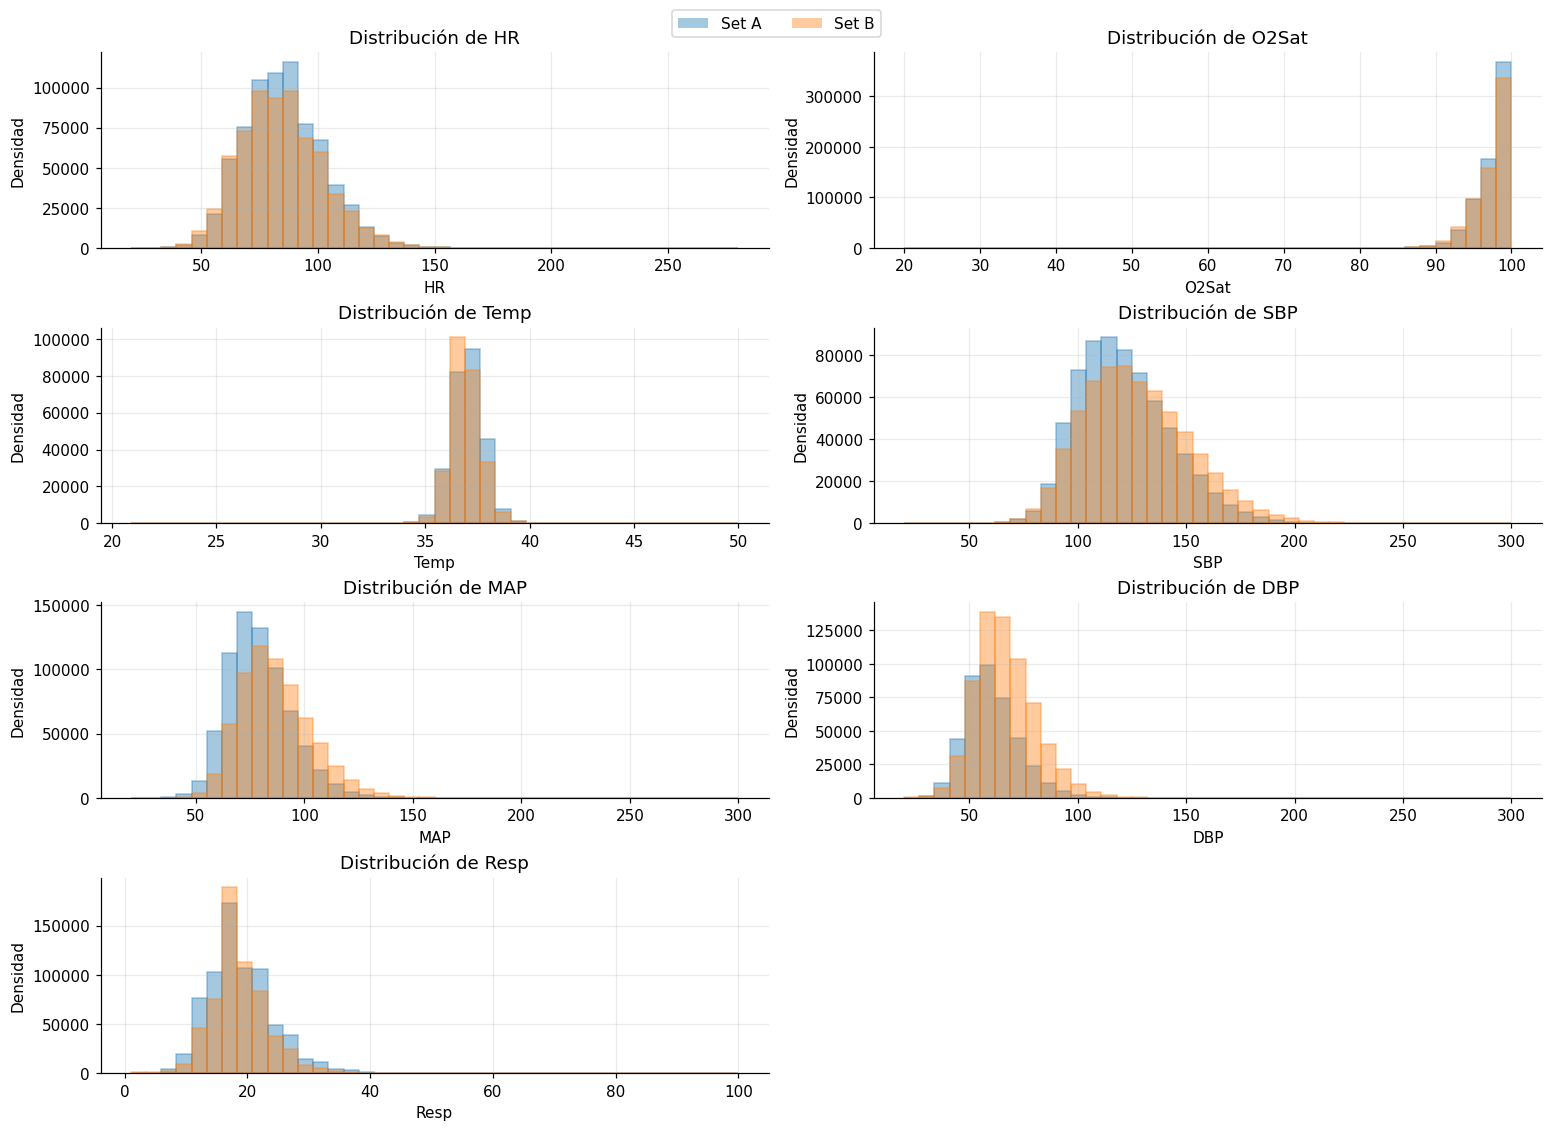

In [9]:
from matplotlib.patches import Patch

variables = DEFAULT_VITALS
colors = {
    "a": "tab:blue",
    "b": "tab:orange",
}

plot_data = data.copy()
plot_data["source_set"] = plot_data["source_set"].str.lower()

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 10),
    constrained_layout=True,
)

for ax, variable in zip(axes.flat, variables):
    variable_data = plot_data[[variable, "source_set"]].dropna()

    # Bins comunes para comparar A y B correctamente
    bins = np.histogram_bin_edges(variable_data[variable], bins=40)

    for source_set in ["a", "b"]:
        values = variable_data.loc[
            variable_data["source_set"] == source_set,
            variable,
        ]

        ax.hist(
            values,
            bins=bins,
            density=False,
            alpha=0.40,
            color=colors[source_set],
            edgecolor=colors[source_set],
            label=f"Set {source_set.upper()}",
        )

    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Densidad")
    ax.grid(alpha=0.25)

axes.flat[-1].axis("off")

legend_handles = [
    Patch(facecolor=colors["a"], alpha=0.40, label="Set A"),
    Patch(facecolor=colors["b"], alpha=0.40, label="Set B"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
)

plt.show()

## 3. ¿Cuánto se observa a cada paciente y qué falta?

`last_hour` es la última hora registrada, no necesariamente la duración completa de hospitalización. El histograma da un voto a cada paciente. La tabla de signos vitales usa todas las filas: las estancias largas aportan más registros. Un faltante no equivale a cero.


,count,mean,std,min,25%,50%,75%,max,missing_pct,unit
HR,1398811.0,84.58,17.33,20.0,72.0,83.5,95.5,280.0,9.88,latidos/min
O2Sat,1349474.0,97.19,2.94,20.0,96.0,98.0,99.5,100.0,13.06,%
Temp,525226.0,36.98,0.77,20.9,36.5,37.0,37.5,50.0,66.16,°C
SBP,1325945.0,123.75,23.23,20.0,107.0,121.0,138.0,300.0,14.58,mmHg
MAP,1358940.0,82.40,16.34,20.0,71.0,80.0,92.0,300.0,12.45,mmHg
DBP,1065656.0,63.83,13.96,20.0,54.0,62.0,72.0,300.0,31.35,mmHg
Resp,1313875.0,18.73,5.10,1.0,15.0,18.0,21.5,100.0,15.35,resp/min


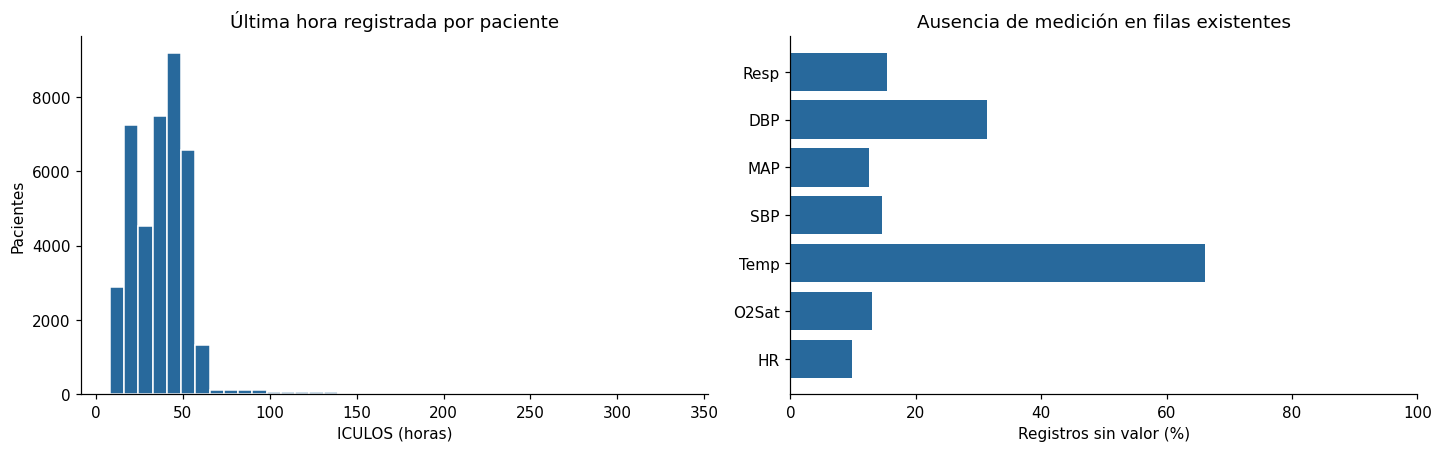

In [4]:
quality = (
    data[DEFAULT_VITALS]
    .describe()
    .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)
quality["missing_pct"] = data[DEFAULT_VITALS].isna().mean() * 100
quality["unit"] = pd.Series(UNITS)
display(quality.round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
axes[0].hist(patient_summary.last_hour, bins=40, color=BLUE, edgecolor="white")
axes[0].set(
    title="Última hora registrada por paciente",
    xlabel="ICULOS (horas)",
    ylabel="Pacientes",
)
axes[1].barh(DEFAULT_VITALS, quality.loc[DEFAULT_VITALS, "missing_pct"], color=BLUE)
axes[1].set(
    title="Ausencia de medición en filas existentes",
    xlabel="Registros sin valor (%)",
    xlim=(0, 100),
)
show_figure(fig, "01_duration_missingness")

## 4. Un paciente: siete series temporales

Si `PATIENT_ID` está vacío, se elige un paciente con duración cercana a la mediana de la muestra (desempate por ID). Esto ofrece un ejemplo reproducible, no un paciente clínicamente representativo.

Cada panel usa sus propias unidades y escala. Los puntos son valores observados; las interrupciones muestran datos faltantes. Se añaden horas ausentes como `NaN` para no unir artificialmente ambos lados de un hueco.


,source_set,first_hour,last_hour,recorded_rows,missing_hour_rows,psv_path
patient_id,,,,,,
a_p000094,a,3,39,37,0,data\raw\tableshift_cache\physionet.org\files\...


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp
ICULOS,,,,,,,
3,78.0,100.0,35.83,149.0,103.0,80.0,14.0
4,78.0,100.0,NaN,164.0,108.0,74.0,20.0
5,76.0,99.0,36.06,148.0,96.0,69.0,19.0
6,75.0,97.0,NaN,157.0,94.0,69.0,18.0
7,79.0,100.0,36.17,153.0,96.0,70.0,17.0
8,72.0,99.0,NaN,149.0,95.0,69.0,18.0
9,71.0,99.0,NaN,165.0,103.0,72.0,13.0
10,72.0,96.0,NaN,153.0,78.0,68.0,15.0
11,74.0,98.0,36.44,141.0,86.0,64.0,12.0


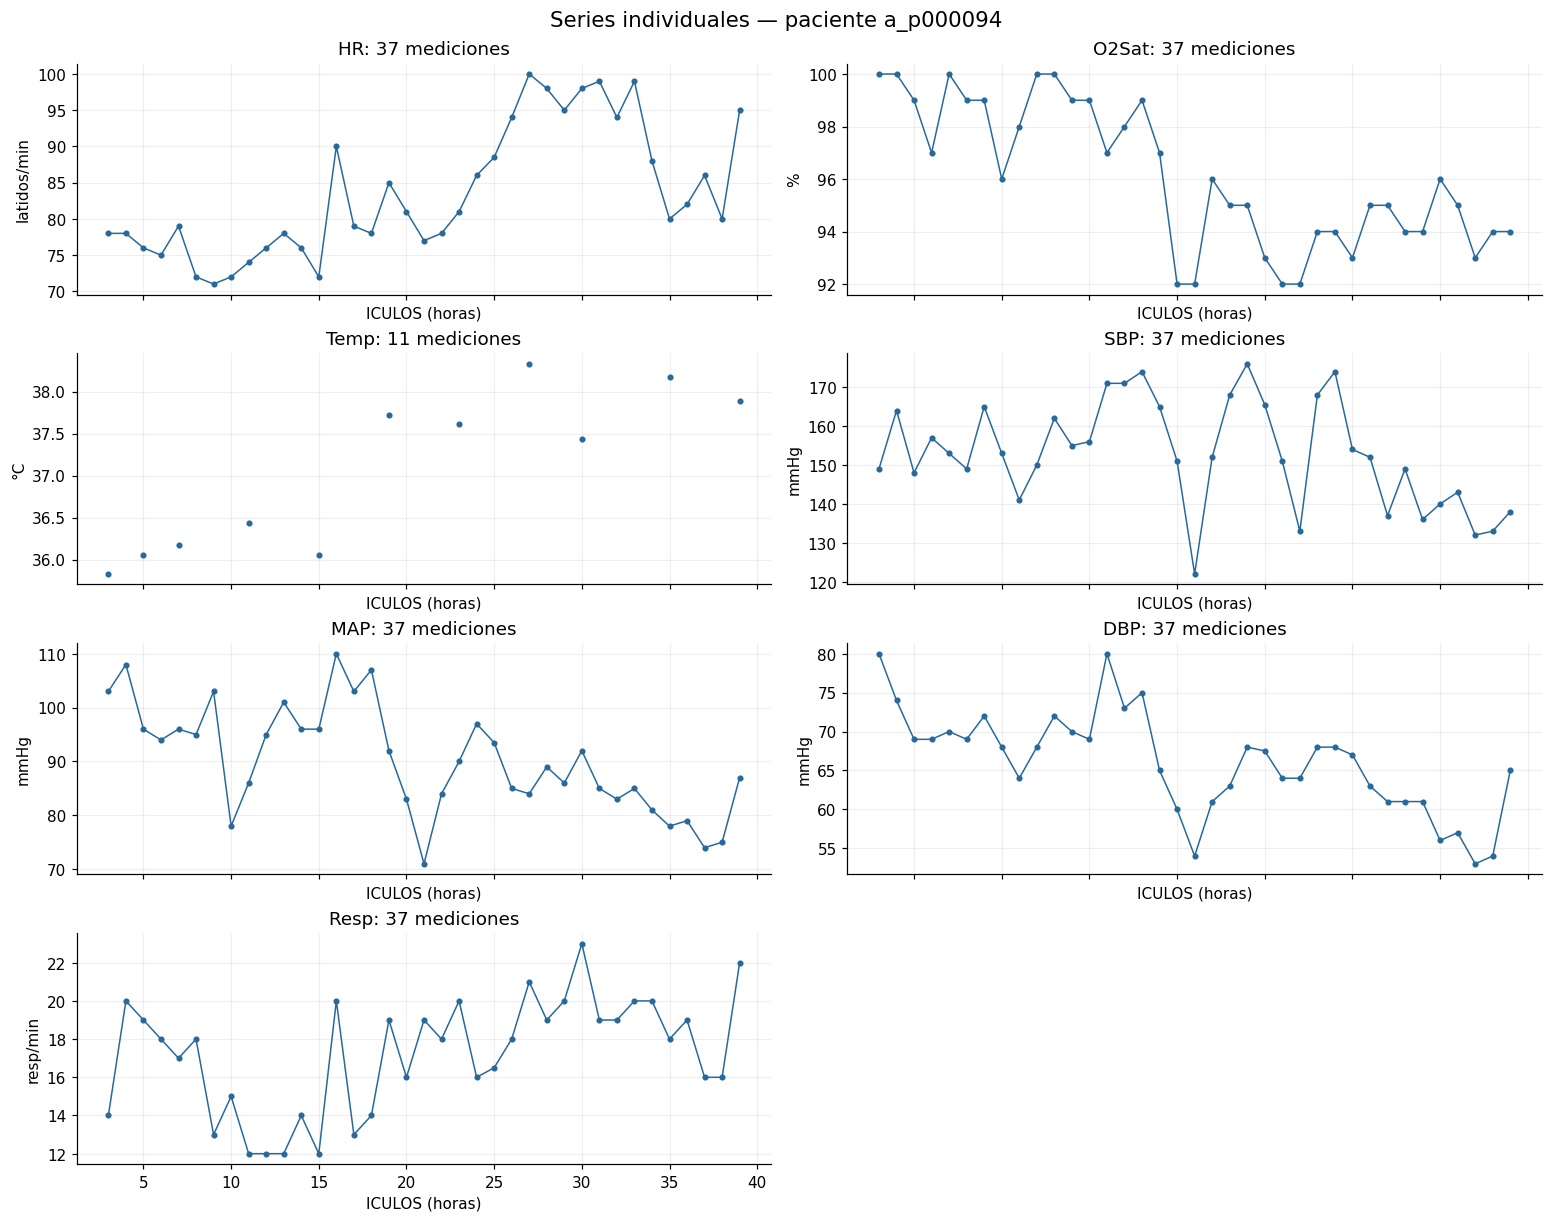

In [5]:
if PATIENT_ID is None:
    distance = (patient_summary.last_hour - patient_summary.last_hour.median()).abs()
    selected_id = distance.sort_values(kind="stable").index[0]
else:
    selected_id = PATIENT_ID
if selected_id not in patient_summary.index:
    raise ValueError(
        f"{selected_id} no está en la muestra; usa un ID de patient_summary."
    )
patient = data.loc[data.patient_id.eq(selected_id)].set_index("ICULOS").sort_index()
hours = np.arange(int(patient.index.min()), int(patient.index.max()) + 1)
series = patient[DEFAULT_VITALS].reindex(hours)
display(patient_summary.loc[[selected_id]])
display(patient[DEFAULT_VITALS].head(10))
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True, layout="constrained")
for ax, vital in zip(axes.flat, DEFAULT_VITALS):
    ax.plot(series.index, series[vital], "o-", color=BLUE, markersize=3, linewidth=1)
    ax.set(
        title=f"{vital}: {series[vital].notna().sum()} mediciones",
        ylabel=UNITS[vital],
        xlabel="ICULOS (horas)",
    )
    ax.grid(alpha=0.2)
axes.flat[-1].axis("off")
fig.suptitle(f"Series individuales — paciente {selected_id}", fontsize=14)
show_figure(fig, "02_patient_series")

### ¿Dónde están las mediciones faltantes de ese paciente?

El mapa permite distinguir una línea estable de una variable casi nunca medida. Gris claro significa sin valor; azul significa medición disponible. No se rellenan huecos.


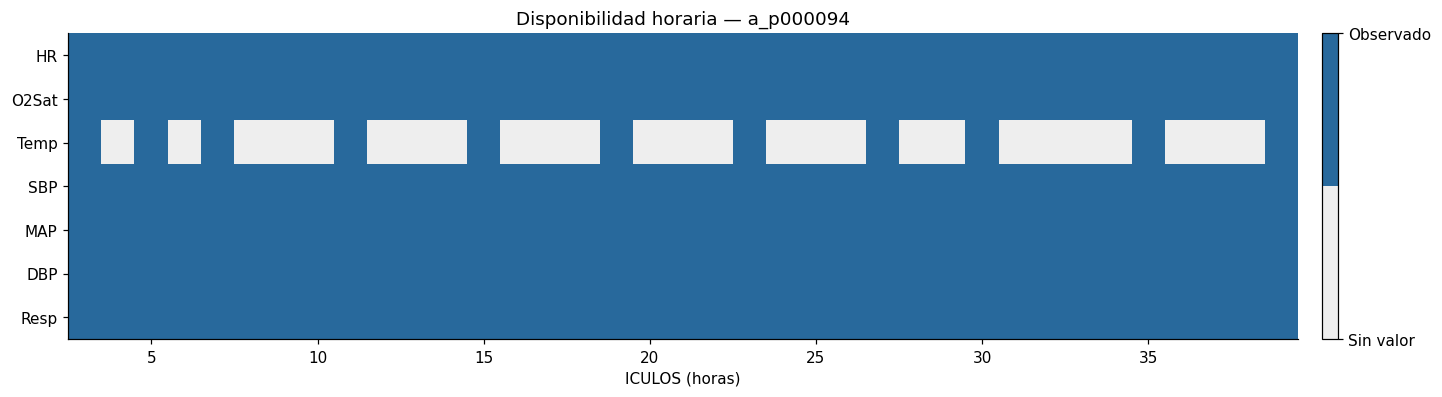

In [6]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(13, 3.5), layout="constrained")
im = ax.imshow(
    series.notna().T,
    aspect="auto",
    interpolation="nearest",
    cmap=ListedColormap(["#eeeeee", BLUE]),
    vmin=0,
    vmax=1,
    extent=[hours[0] - 0.5, hours[-1] + 0.5, 6.5, -0.5],
)
ax.set_yticks(range(7), DEFAULT_VITALS)
ax.set(title=f"Disponibilidad horaria — {selected_id}", xlabel="ICULOS (horas)")
bar = fig.colorbar(im, ax=ax, ticks=[0, 1], pad=0.02)
bar.ax.set_yticklabels(["Sin valor", "Observado"])
show_figure(fig, "03_patient_availability")

## 5. Varios pacientes alineados por ICULOS

Se seleccionan tres ejemplos cercanos a los percentiles 25, 50 y 75 de última hora registrada. Cada línea conserva la identidad de un paciente; no se concatenan sus registros. La misma coordenada X significa la misma hora relativa desde el ingreso.


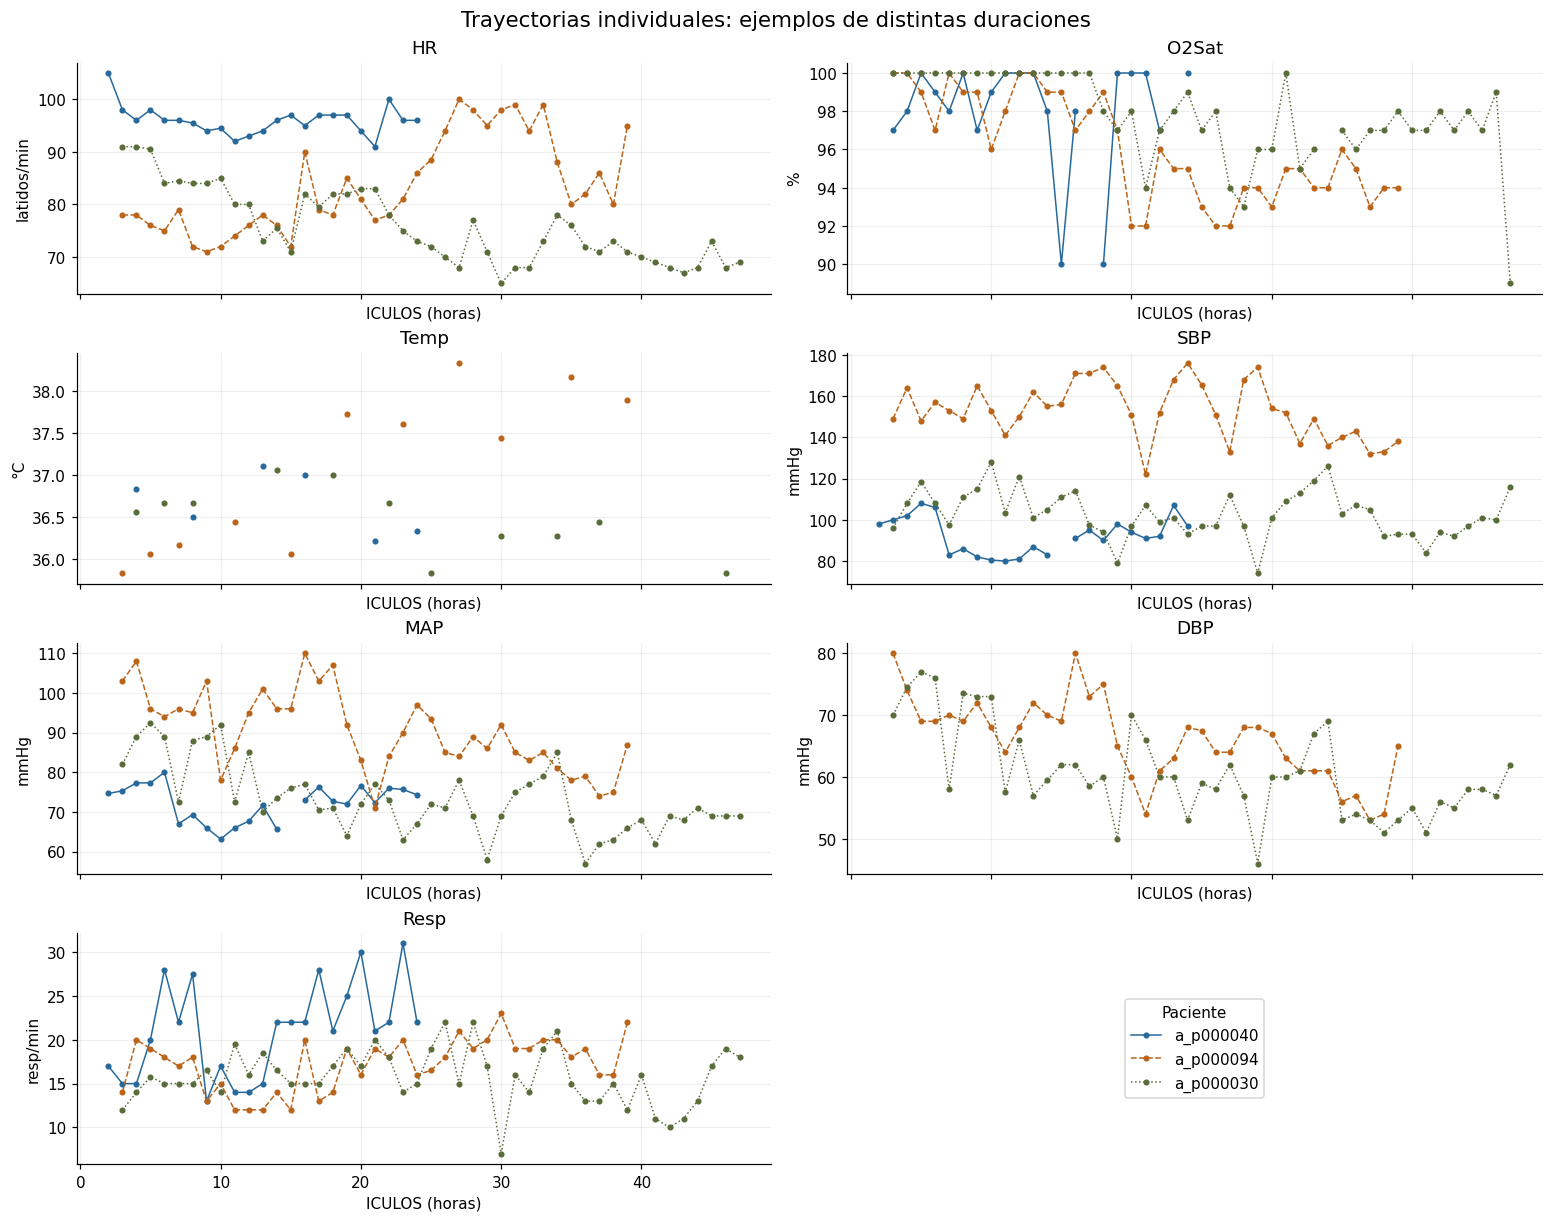

In [7]:
example_ids = []
for quantile in [0.25, 0.5, 0.75]:
    candidates = (
        (patient_summary.last_hour - patient_summary.last_hour.quantile(quantile))
        .abs()
        .sort_values(kind="stable")
    )
    example_ids.append(next(pid for pid in candidates.index if pid not in example_ids))
colors = [BLUE, ORANGE, "#596c39"]
styles = ["-", "--", ":"]
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True, layout="constrained")
for pid, color, style in zip(example_ids, colors, styles):
    frame = data.loc[data.patient_id.eq(pid) & data.ICULOS.le(MAX_HOUR)].set_index(
        "ICULOS"
    )
    frame = frame.reindex(
        range(1, min(MAX_HOUR, int(patient_summary.loc[pid, "last_hour"])) + 1)
    )
    for ax, vital in zip(axes.flat, DEFAULT_VITALS):
        ax.plot(
            frame.index,
            frame[vital],
            marker=".",
            linestyle=style,
            color=color,
            label=pid,
            linewidth=1,
        )
        ax.set(title=vital, ylabel=UNITS[vital], xlabel="ICULOS (horas)")
        ax.grid(alpha=0.2)
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[-1].axis("off")
axes.flat[-1].legend(handles, labels, loc="center", title="Paciente")
fig.suptitle("Trayectorias individuales: ejemplos de distintas duraciones", fontsize=14)
show_figure(fig, "04_multiple_patients")

## Con y sin Sepsis


## 6. Población: valores y disponibilidad en cada hora

Ahora cada hora reúne pacientes distintos o repetidos que tienen un registro en esa hora. Línea = mediana; banda = percentiles 25–75 entre pacientes (no intervalo de confianza). El panel final muestra cuántos pacientes aportan un valor de cada signo. Una mediana estable puede coexistir con trayectorias individuales variables.

El mapa de faltantes divide, en cada hora, valores ausentes entre filas existentes. Los pacientes sin fila en esa hora quedan fuera de ese denominador.


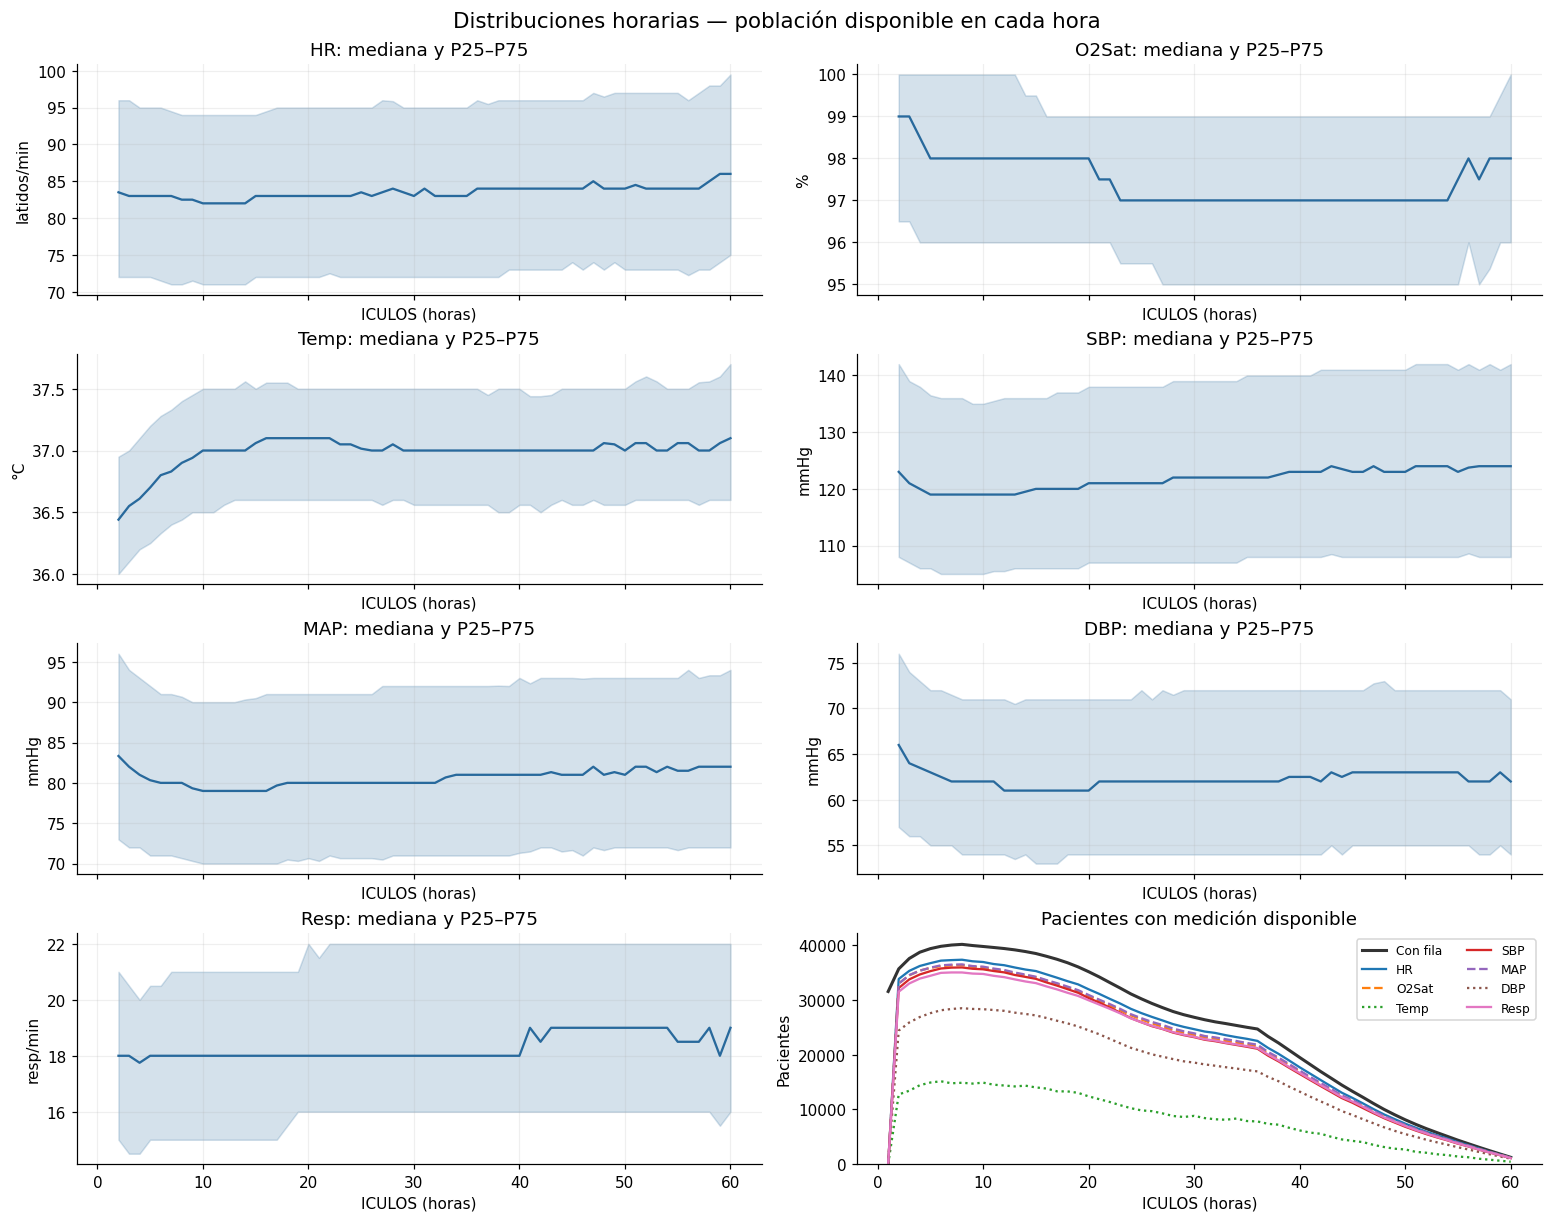

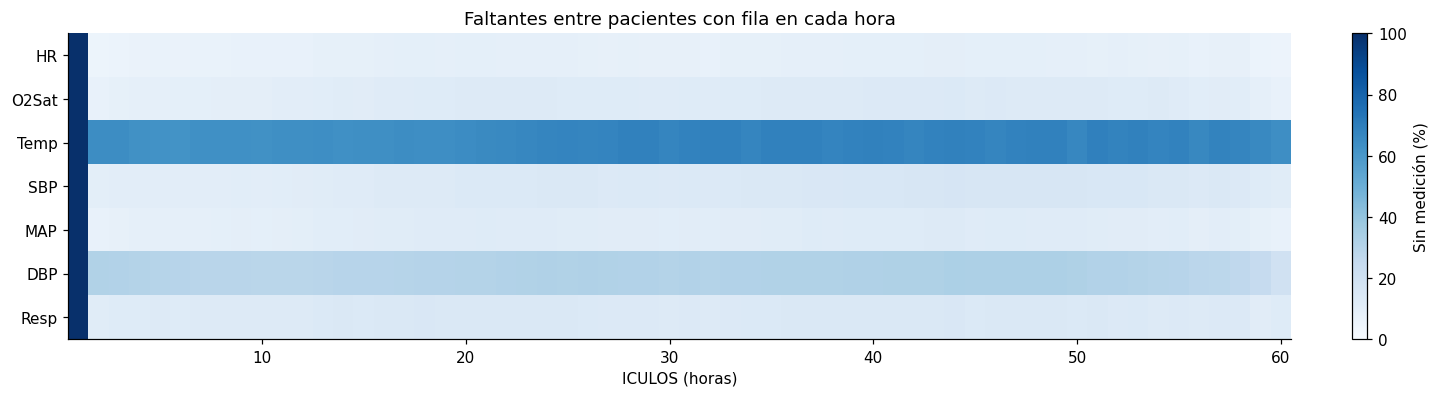

In [8]:
hourly_data = data.loc[data.ICULOS.between(1, MAX_HOUR)].copy()
hour_index = pd.Index(range(1, MAX_HOUR + 1), name="ICULOS")
hour_groups = hourly_data.groupby("ICULOS")[DEFAULT_VITALS]
hour_median = hour_groups.median().reindex(hour_index)
hour_q25 = hour_groups.quantile(0.25).reindex(hour_index)
hour_q75 = hour_groups.quantile(0.75).reindex(hour_index)
hour_counts = hour_groups.count().reindex(hour_index, fill_value=0)
hour_patients = (
    hourly_data.groupby("ICULOS").patient_id.nunique().reindex(hour_index, fill_value=0)
)
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True, layout="constrained")
for ax, vital in zip(axes.flat, DEFAULT_VITALS):
    ax.plot(hour_index, hour_median[vital], color=BLUE)
    ax.fill_between(hour_index, hour_q25[vital], hour_q75[vital], color=BLUE, alpha=0.2)
    ax.set(
        title=f"{vital}: mediana y P25–P75",
        ylabel=UNITS[vital],
        xlabel="ICULOS (horas)",
    )
    ax.grid(alpha=0.2)
ax = axes.flat[-1]
ax.plot(hour_index, hour_patients, color="#333333", label="Con fila", linewidth=2)
for i, vital in enumerate(DEFAULT_VITALS):
    ax.plot(
        hour_index, hour_counts[vital], label=vital, linestyle=["-", "--", ":"][i % 3]
    )
ax.set(
    title="Pacientes con medición disponible",
    xlabel="ICULOS (horas)",
    ylabel="Pacientes",
    ylim=(0, None),
)
ax.legend(ncol=2, fontsize=8)
fig.suptitle("Distribuciones horarias — población disponible en cada hora", fontsize=14)
show_figure(fig, "05_hourly_population")

missing_by_hour = (1 - hour_counts.div(hour_patients.replace(0, np.nan), axis=0)) * 100
fig, ax = plt.subplots(figsize=(13, 3.5), layout="constrained")
im = ax.imshow(
    missing_by_hour.T,
    aspect="auto",
    vmin=0,
    vmax=100,
    cmap="Blues",
    extent=[0.5, MAX_HOUR + 0.5, 6.5, -0.5],
    interpolation="nearest",
)
ax.set_yticks(range(7), DEFAULT_VITALS)
ax.set(title="Faltantes entre pacientes con fila en cada hora", xlabel="ICULOS (horas)")
fig.colorbar(im, ax=ax, label="Sin medición (%)")
show_figure(fig, "06_hourly_missingness")

## 7. ¿Qué cambia al agrupar de tres en tres?

Esta sección reproduce explícitamente la regla del notebook anterior: selecciona **la última fila del paciente dentro del intervalo**. No calcula una media ni busca el último valor no nulo por signo. Si HR falta en esa fila, sigue faltando aunque exista en una hora anterior.

Las cajas resumen los valores no nulos de esa última fila, una por paciente y ventana. Incluyen 1–3 y 4–6. Línea central = mediana; caja = P25–P75; bigotes = hasta 1.5 veces el rango intercuartílico; puntos = valores exteriores, no necesariamente errores. El mapa inferior muestra el número real de valores por signo y ventana.


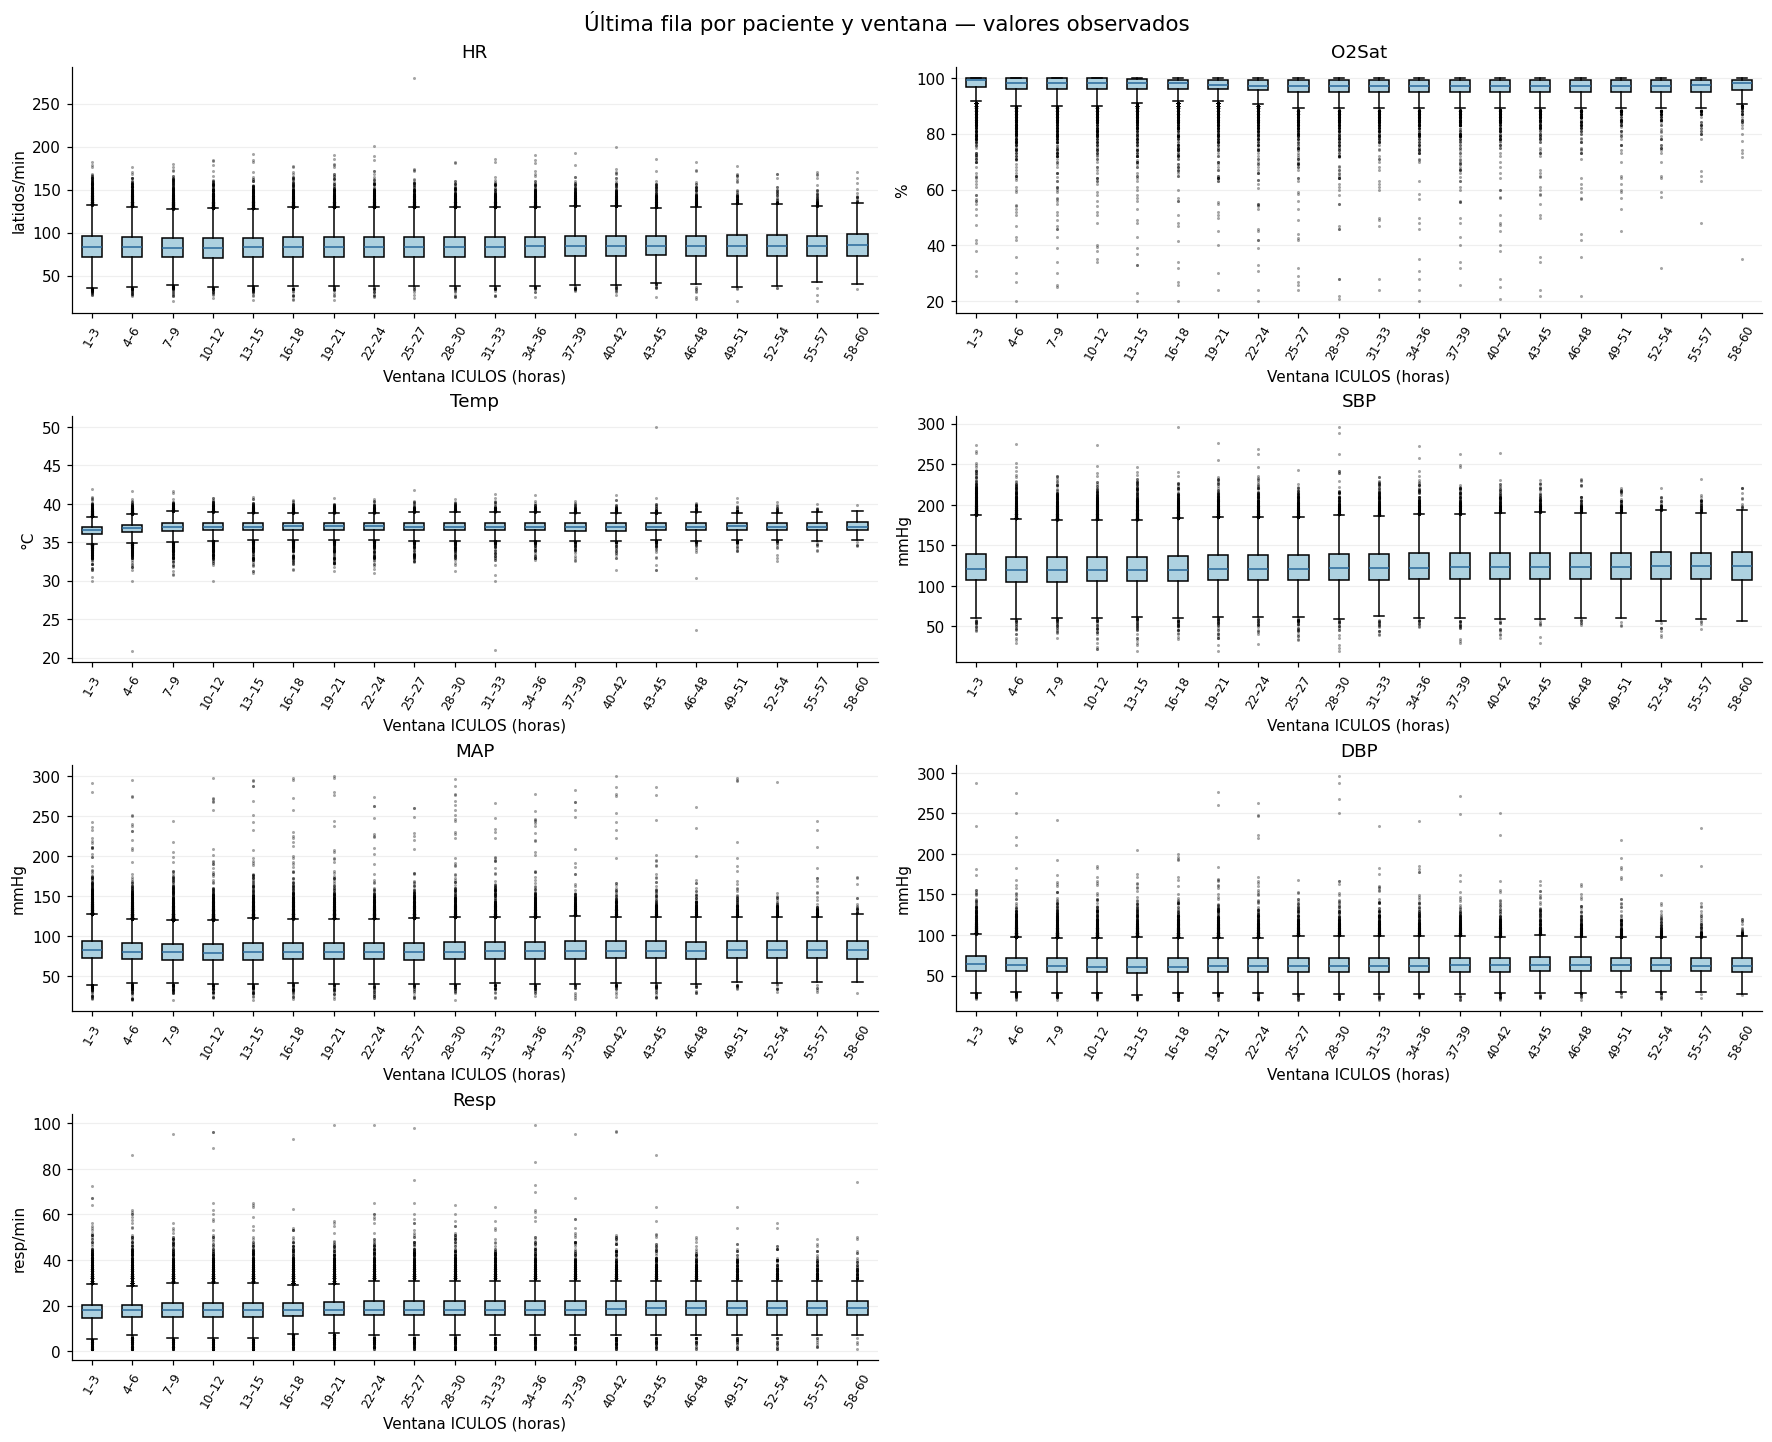

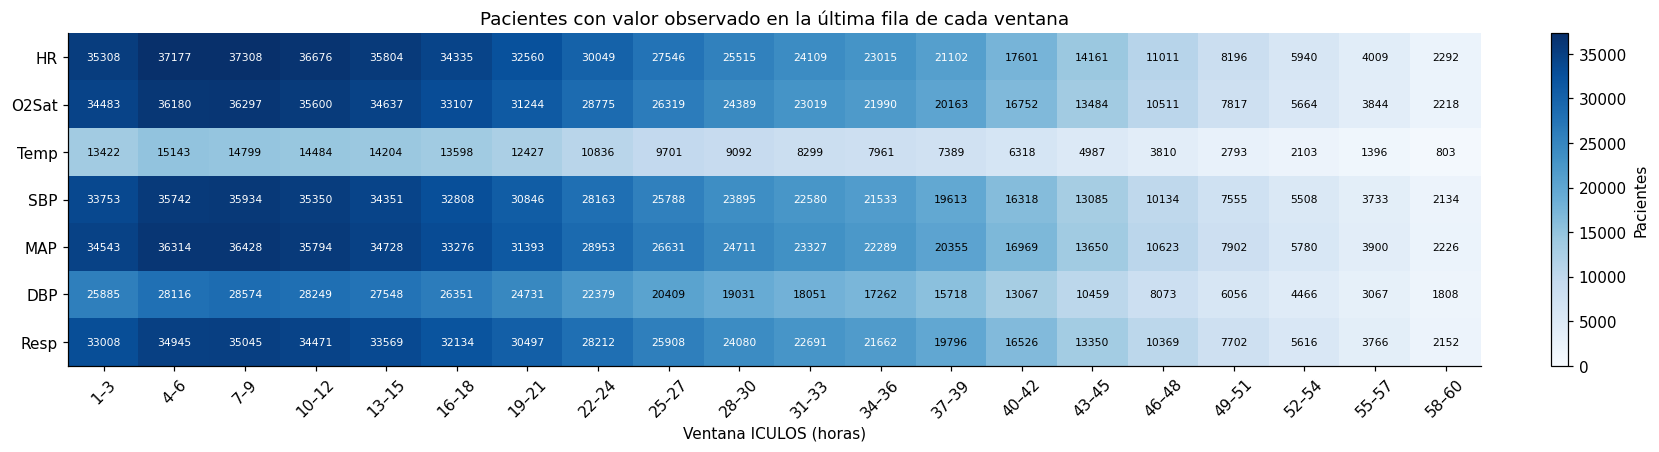

,patient_id,window_start,ICULOS,HR,O2Sat,Temp,SBP,MAP,DBP,Resp
3465,a_p000094,1,3,78.0,100.0,35.83,149.0,103.0,80.0,14.0
3468,a_p000094,4,6,75.0,97.0,NaN,157.0,94.0,69.0,18.0
3471,a_p000094,7,9,71.0,99.0,NaN,165.0,103.0,72.0,13.0
3474,a_p000094,10,12,76.0,100.0,NaN,150.0,95.0,68.0,12.0
3477,a_p000094,13,15,72.0,99.0,36.06,156.0,96.0,69.0,12.0
3480,a_p000094,16,18,78.0,99.0,NaN,174.0,107.0,75.0,14.0
3483,a_p000094,19,21,77.0,92.0,NaN,122.0,71.0,54.0,19.0
3486,a_p000094,22,24,86.0,95.0,NaN,176.0,97.0,68.0,16.0


In [9]:
hourly_data["window_start"] = (
    1 + ((hourly_data.ICULOS - 1) // WINDOW_HOURS).astype(int) * WINDOW_HOURS
)
window_data = (
    hourly_data.sort_values(["patient_id", "ICULOS"])
    .groupby(["patient_id", "window_start"], sort=False)
    .tail(1)
)
starts = list(range(1, MAX_HOUR + 1, WINDOW_HOURS))
labels = [f"{start}–{min(start + WINDOW_HOURS - 1, MAX_HOUR)}" for start in starts]
assert not window_data.duplicated(["patient_id", "window_start"]).any()
fig, axes = plt.subplots(4, 2, figsize=(16, 13), layout="constrained")
for ax, vital in zip(axes.flat, DEFAULT_VITALS):
    values = [
        window_data.loc[window_data.window_start.eq(start), vital].dropna().to_numpy()
        for start in starts
    ]
    ax.boxplot(
        values,
        tick_labels=labels,
        patch_artist=True,
        boxprops={"facecolor": "#add1e0"},
        medianprops={"color": BLUE},
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.35},
    )
    ax.set(title=vital, ylabel=UNITS[vital], xlabel="Ventana ICULOS (horas)")
    ax.tick_params(axis="x", labelrotation=60, labelsize=8)
    ax.grid(axis="y", alpha=0.2)
axes.flat[-1].axis("off")
fig.suptitle("Última fila por paciente y ventana — valores observados", fontsize=14)
show_figure(fig, "07_window_distributions")

window_counts = (
    window_data.groupby("window_start")[DEFAULT_VITALS]
    .count()
    .reindex(starts, fill_value=0)
)
fig, ax = plt.subplots(figsize=(15, 4), layout="constrained")
im = ax.imshow(window_counts.T, aspect="auto", cmap="Blues", vmin=0)
ax.set_xticks(range(len(labels)), labels, rotation=45)
ax.set_yticks(range(7), DEFAULT_VITALS)
for i, vital in enumerate(DEFAULT_VITALS):
    for j, start in enumerate(starts):
        value = window_counts.loc[start, vital]
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=7,
            color="white" if value > window_counts.to_numpy().max() * 0.55 else "black",
        )
ax.set(
    title="Pacientes con valor observado en la última fila de cada ventana",
    xlabel="Ventana ICULOS (horas)",
)
fig.colorbar(im, ax=ax, label="Pacientes")
show_figure(fig, "08_window_counts")
display(
    window_data.loc[
        window_data.patient_id.eq(selected_id),
        ["patient_id", "window_start", "ICULOS", *DEFAULT_VITALS],
    ].head(8)
)

## 8. Comparar las mismas personas: horas 1–6 frente a 19–24

Para reducir el efecto de cambiar de pacientes, calculamos la mediana de cada signo dentro de cada periodo y emparejamos por paciente. Aquí **sí usamos la mediana del periodo**, a diferencia de la última fila de la sección anterior.

Cada punto representa una persona con datos en ambos periodos: X = mediana temprana, Y = mediana tardía. Sobre la diagonal: aumento; debajo: disminución. Se incluyen todos los pares disponibles para cada signo y se muestra su tamaño. La selección favorece estancias largas y personas medidas en ambos periodos; no elimina todos los sesgos. Es una descripción pareada, no una prueba de drift o de causalidad.


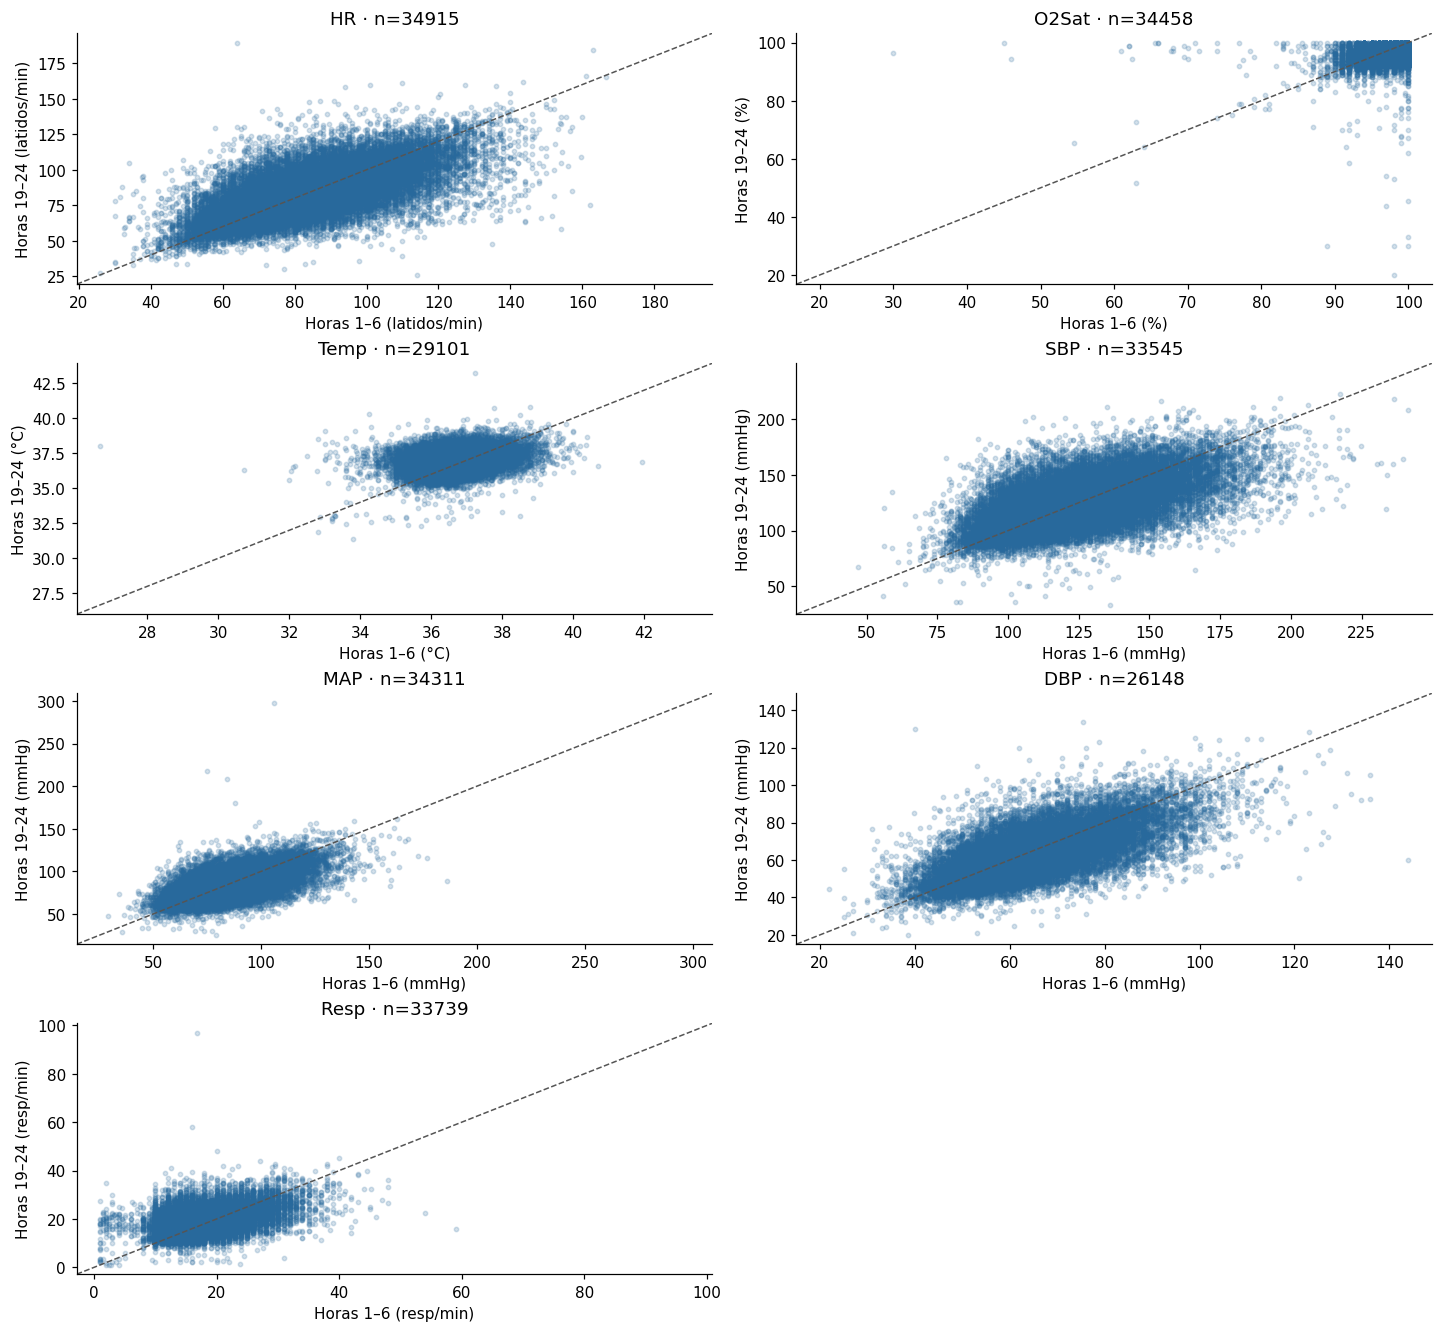

,pacientes_pareados,mediana_cambio,P25_cambio,P75_cambio,unidad
signo,,,,,
HR,34915,0.00,-8.00,7.50,latidos/min
O2Sat,34458,-0.50,-2.00,0.50,%
Temp,29101,0.20,-0.25,0.78,°C
SBP,33545,0.25,-11.00,11.50,mmHg
MAP,34311,-1.00,-8.55,6.66,mmHg
DBP,26148,-1.50,-8.00,4.50,mmHg
Resp,33739,0.75,-2.00,3.50,resp/min


In [10]:
early = (
    data.loc[data.ICULOS.between(1, 6)].groupby("patient_id")[DEFAULT_VITALS].median()
)
late = (
    data.loc[data.ICULOS.between(19, 24)].groupby("patient_id")[DEFAULT_VITALS].median()
)
paired_rows = []
fig, axes = plt.subplots(4, 2, figsize=(13, 12), layout="constrained")
for ax, vital in zip(axes.flat, DEFAULT_VITALS):
    pairs = pd.concat(
        [early[vital].rename("early"), late[vital].rename("late")], axis=1
    ).dropna()
    delta = pairs.late - pairs.early
    paired_rows.append(
        {
            "signo": vital,
            "pacientes_pareados": len(pairs),
            "mediana_cambio": delta.median(),
            "P25_cambio": delta.quantile(0.25),
            "P75_cambio": delta.quantile(0.75),
            "unidad": UNITS[vital],
        }
    )
    ax.scatter(pairs.early, pairs.late, s=8, alpha=0.2, color=BLUE, rasterized=True)
    if len(pairs):
        low, high = pairs.to_numpy().min(), pairs.to_numpy().max()
        margin = max((high - low) * 0.04, 0.1)
        ax.plot(
            [low - margin, high + margin],
            [low - margin, high + margin],
            "--",
            color="#555555",
            linewidth=1,
        )
        ax.set_xlim(low - margin, high + margin)
        ax.set_ylim(low - margin, high + margin)
    ax.set(
        title=f"{vital} · n={len(pairs)}",
        xlabel=f"Horas 1–6 ({UNITS[vital]})",
        ylabel=f"Horas 19–24 ({UNITS[vital]})",
    )
axes.flat[-1].axis("off")
show_figure(fig, "09_paired_periods")
paired_summary = pd.DataFrame(paired_rows).set_index("signo")
display(paired_summary.round(2))

## 9. Comprobaciones y lectura final

La calidad temporal se verifica por paciente: no se interpretan saltos entre dos pacientes como cambios de una misma serie. Las cifras siguientes se calculan sobre esta ejecución. Ninguna comparación diagnostica clínicamente a los pacientes ni demuestra concept drift.


In [11]:
assert (hour_counts.le(hour_patients, axis=0)).all().all()
assert window_counts.sum().eq(window_data[DEFAULT_VITALS].notna().sum()).all()
raw_example = pd.read_csv(ROOT / patient_summary.loc[selected_id, "psv_path"], sep="|")
pd.testing.assert_frame_equal(
    raw_example[["ICULOS", *DEFAULT_VITALS]].reset_index(drop=True),
    patient.reset_index()[["ICULOS", *DEFAULT_VITALS]].reset_index(drop=True),
    check_dtype=False,
)
most_missing = quality.missing_pct.idxmax()
display(
    Markdown(
        f"- Se cargaron **{len(patient_summary):,} pacientes** y **{len(data):,} filas**.\n"
        f"- La mediana de última hora registrada es **{patient_summary.last_hour.median():.0f} h**.\n"
        f"- **{most_missing}** presenta el mayor porcentaje faltante: **{quality.loc[most_missing, 'missing_pct']:.1f}%** de filas.\n"
        f"- Hay **{hour_patients.loc[1]:,} pacientes con fila en la hora 1** y **{hour_patients.loc[MAX_HOUR]:,} en la hora {MAX_HOUR}**.\n"
        f"- La comparación pareada dispone de entre **{paired_summary.pacientes_pareados.min():,} y {paired_summary.pacientes_pareados.max():,} pacientes**, según el signo.\n"
        "- Comprobaciones de orden, duplicados, denominadores y correspondencia del archivo de ejemplo: **correctas**."
    )
)

- Se cargaron **40,336 pacientes** y **1,552,210 filas**.
- La mediana de última hora registrada es **39 h**.
- **Temp** presenta el mayor porcentaje faltante: **66.2%** de filas.
- Hay **31,543 pacientes con fila en la hora 1** y **1,260 en la hora 60**.
- La comparación pareada dispone de entre **26,148 y 34,915 pacientes**, según el signo.
- Comprobaciones de orden, duplicados, denominadores y correspondencia del archivo de ejemplo: **correctas**.

### Qué puedes concluir con este notebook

1. **Serie individual:** cómo varía un signo en una persona y dónde faltan mediciones.
2. **Comparación horaria:** cómo se distribuyen los valores entre quienes tienen datos en esa hora. La banda describe dispersión entre personas.
3. **Ventanas de tres horas:** cómo cambia la visualización al conservar una fila por paciente e intervalo. Esta regla descarta información horaria; no es obligatoria para hacer EDA.
4. **Comparación pareada:** cuánto cambian los signos de las mismas personas entre dos periodos, con cobertura explícita.

Los boxplots parecidos no prueban ausencia de todo cambio: pueden ocultar trayectorias distintas, dependencias entre signos y falta de datos. Tampoco un cambio clínico por ICULOS demuestra drift del modelo. Este EDA prepara el conocimiento de los datos; evaluar detección y adaptación requiere un protocolo adicional y una secuencia de evaluación definida.

**Salidas:** las figuras quedan embebidas en este notebook y en `outputs/figures/physionet_vitals_eda/`. Los datos originales permanecen en su ruta local. No se requieren los objetos `poc` ni un modelo entrenado.
